In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.005 # In [fm^-2]
ENDING_RANGE_PARAMETER = 50
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 80 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [2]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def super_symmetric_potential_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, k_value, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                                       central_potential_param)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [3]:
def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix


def susy_correction_mat_gen(tot_ang_momentum, orb_ang_momentum, k_value, theta, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix


def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [4]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 3.3790962073634264e+16
The S state eigenvalues are [-3.97191215e+01 -8.60692189e+00 -2.92477531e-01  1.18129300e-02
  4.77457289e-02  1.09403427e-01  1.99797978e-01  3.23713832e-01
  4.88136344e-01  7.02806448e-01  9.80971306e-01  1.34037885e+00
  1.80454350e+00  2.40434555e+00  3.18013038e+00  4.18468545e+00
  5.48778679e+00  7.18312359e+00  9.39707558e+00  1.22947003e+01
  1.60780188e+01  2.09827221e+01  2.72935346e+01  3.53963857e+01
  4.58496614e+01  5.94257229e+01  7.71116627e+01  1.00103342e+02
  1.29809683e+02  1.67853936e+02  2.16041569e+02  2.76347138e+02
  3.51332926e+02  4.45463381e+02  5.66125593e+02  7.22913436e+02
  9.26879818e+02  1.19094109e+03  1.53056034e+03  1.96424904e+03
  2.51412719e+03  3.20708973e+03  4.07702106e+03  5.16739187e+03
  6.53326843e+03  8.24503907e+03  1.03953156e+04  1.31017366e+04
  1.65038400e+04  2.07659091e+04  2.60839765e+04  3.26839634e+04
  4.08375170e+04  5.09520514e+04  6.36816055e+04  7.9904665

Ground state wavefunction has overlap 0.9999999999999991 with itself


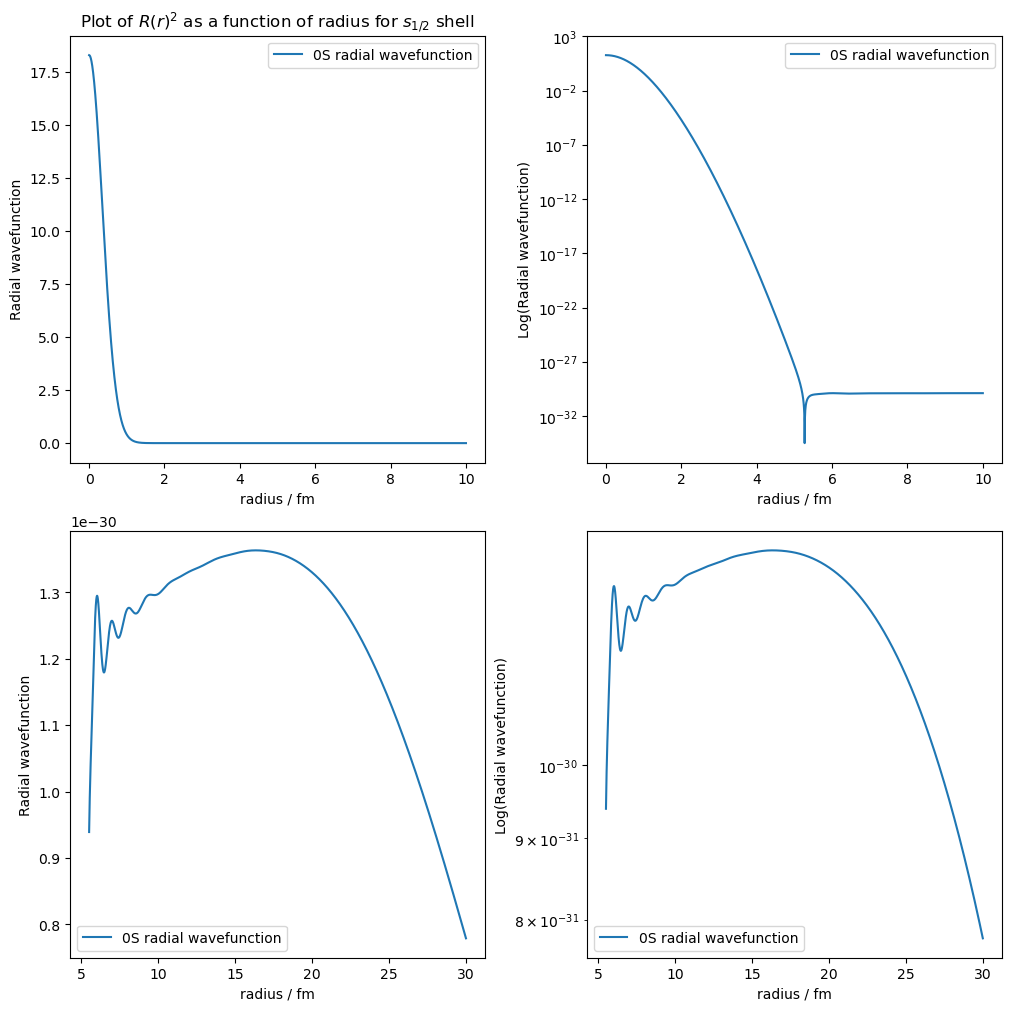

In [5]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients, j_mixing_coefficients, overlap_matrix=None, size=SUM_LIMIT):
    try:
        _ = overlap_matrix.shape
        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
    except AttributeError:
        overlap_matrix = np.zeros(shape=(size, size))

        for i in range(size):
            i_range_parameter = next_range_parameter(i)
            for j in range(size):
                j_range_parameter = next_range_parameter(j)
                overlap_matrix[i, j] = different_l_overlap_matrix_element(orb_ang_momentum_i, orb_ang_momentum_j, i_range_parameter, j_range_parameter)

        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
print(f'Ground state wavefunction has overlap {wavefunction_overlap(0, 0, s0_eigenvector, s0_eigenvector, overlap_matrix=s_n_matrix)} with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = 1 / (next_range_parameter(j))**(0.5)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_4.legend()



In [6]:
def gauss_normalisation(range_param):
    return (2 / (np.pi * (range_param**2)))**(0.75)

def gauss_wavefunc(radius, range_param):
    return gauss_normalisation(range_param) * np.exp(- radius**2 / range_param**2)

def gauss_wavefunc_first_derivitave(radius, range_param):
    return - (2 * radius) / (range_param**2) * gauss_wavefunc(radius, range_param)

def gauss_wavefunc_second_derivitave(radius, range_param):
    return (2 / range_param**2) * (((2 * radius**2) / range_param**2) - 1) * gauss_wavefunc(radius, range_param)

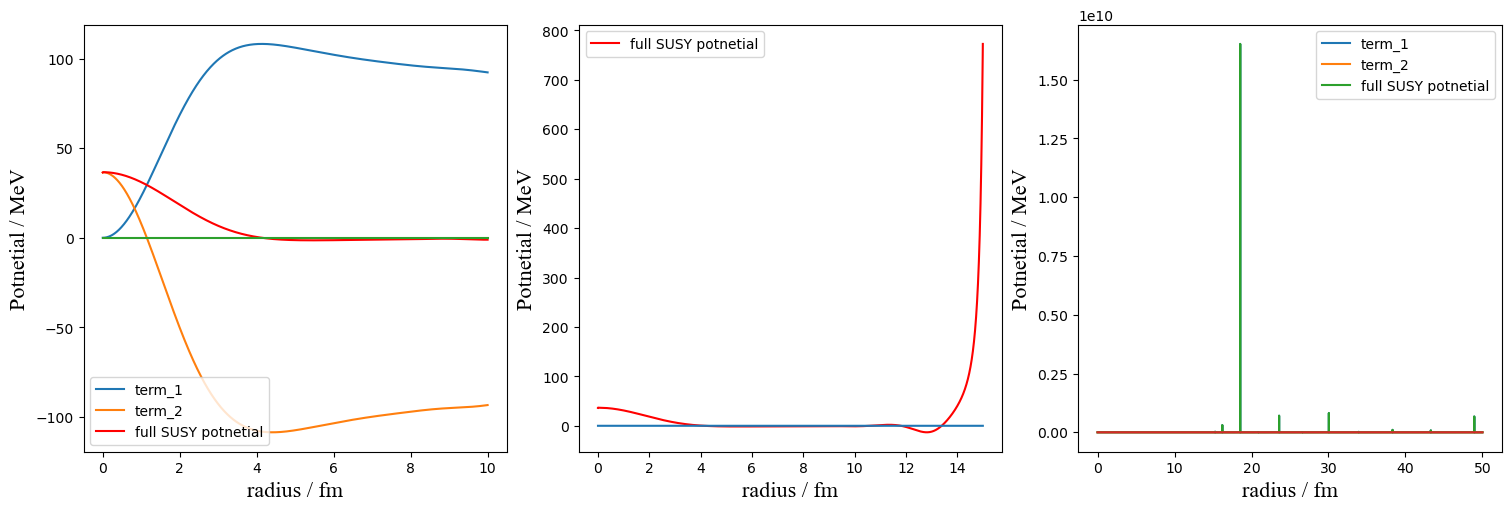

In [10]:
def susy_potential_plot_function(radius, mixing_coeffs, size=SUM_LIMIT):
    susy_term_1_vals = np.zeros(shape=(len(radius),))
    susy_term_2_vals = np.zeros(shape=(len(radius),))

    mixing_coeffs = np.real(mixing_coeffs)
    for i in enumerate(radius):
        term_A = 0
        term_B = 0
        term_C = 0
        for k in enumerate(mixing_coeffs):
            range_parameter = next_range_parameter(k[0])
            term_A += gauss_wavefunc(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_B += gauss_wavefunc_first_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_C += gauss_wavefunc_second_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
        susy_term_1_vals[i[0]] = (197**2 / REDUCED_MASS) * (term_B / term_A)**2
        susy_term_2_vals[i[0]] = -(197**2 / REDUCED_MASS) * (term_C / term_A)

    return susy_term_1_vals, susy_term_2_vals


r_vals = np.linspace(0, 10, 1000)
r_vals_2 = np.linspace(0, 15, 10000)
r_vals_3 = np.linspace(0, 50, 10000)
susy_term_1_vals, susy_term_2_vals = susy_potential_plot_function(r_vals, s_eigenvectors[:, 0])
susy_term_1_vals_2, susy_term_2_vals_2 = susy_potential_plot_function(r_vals_2, s_eigenvectors[:, 0])
susy_term_1_vals_3, susy_term_2_vals_3 = susy_potential_plot_function(r_vals_3, s_eigenvectors[:, 0])

#exporting data to fit in mathematica
fitting_data = np.column_stack((r_vals, susy_term_1_vals + susy_term_2_vals))
np.savetxt("susy_potential_data.csv", fitting_data, delimiter = ",")


fig = plt.figure(figsize=(15, 5), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=1)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[0,2])

ax_1.plot(r_vals, susy_term_1_vals, label='term_1')
ax_1.plot(r_vals, susy_term_2_vals, label='term_2')
ax_1.plot(r_vals, susy_term_1_vals + susy_term_2_vals, label='full SUSY potnetial', color='r')
ax_1.legend()
ax_1.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_1.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_1.plot(r_vals, r_vals*0)

#ax_2.plot(r_vals_2, susy_term_1_vals_2, label='term_1')
#ax_2.plot(r_vals_2, susy_term_2_vals_2, label='term_2')
ax_2.plot(r_vals_2, susy_term_1_vals_2 + susy_term_2_vals_2, label='full SUSY potnetial', color='r')
ax_2.legend()
ax_2.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_2.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_2.plot(r_vals_2, r_vals_2*0)

ax_3.plot(r_vals_3, susy_term_1_vals_3, label='term_1')
ax_3.plot(r_vals_3, susy_term_2_vals_3, label='term_2')
ax_3.plot(r_vals_3, susy_term_1_vals_3 + susy_term_2_vals_3, label='full SUSY potnetial')
ax_3.legend()
ax_3.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_3.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_3.plot(r_vals_3, r_vals_2*0)



0
1
2


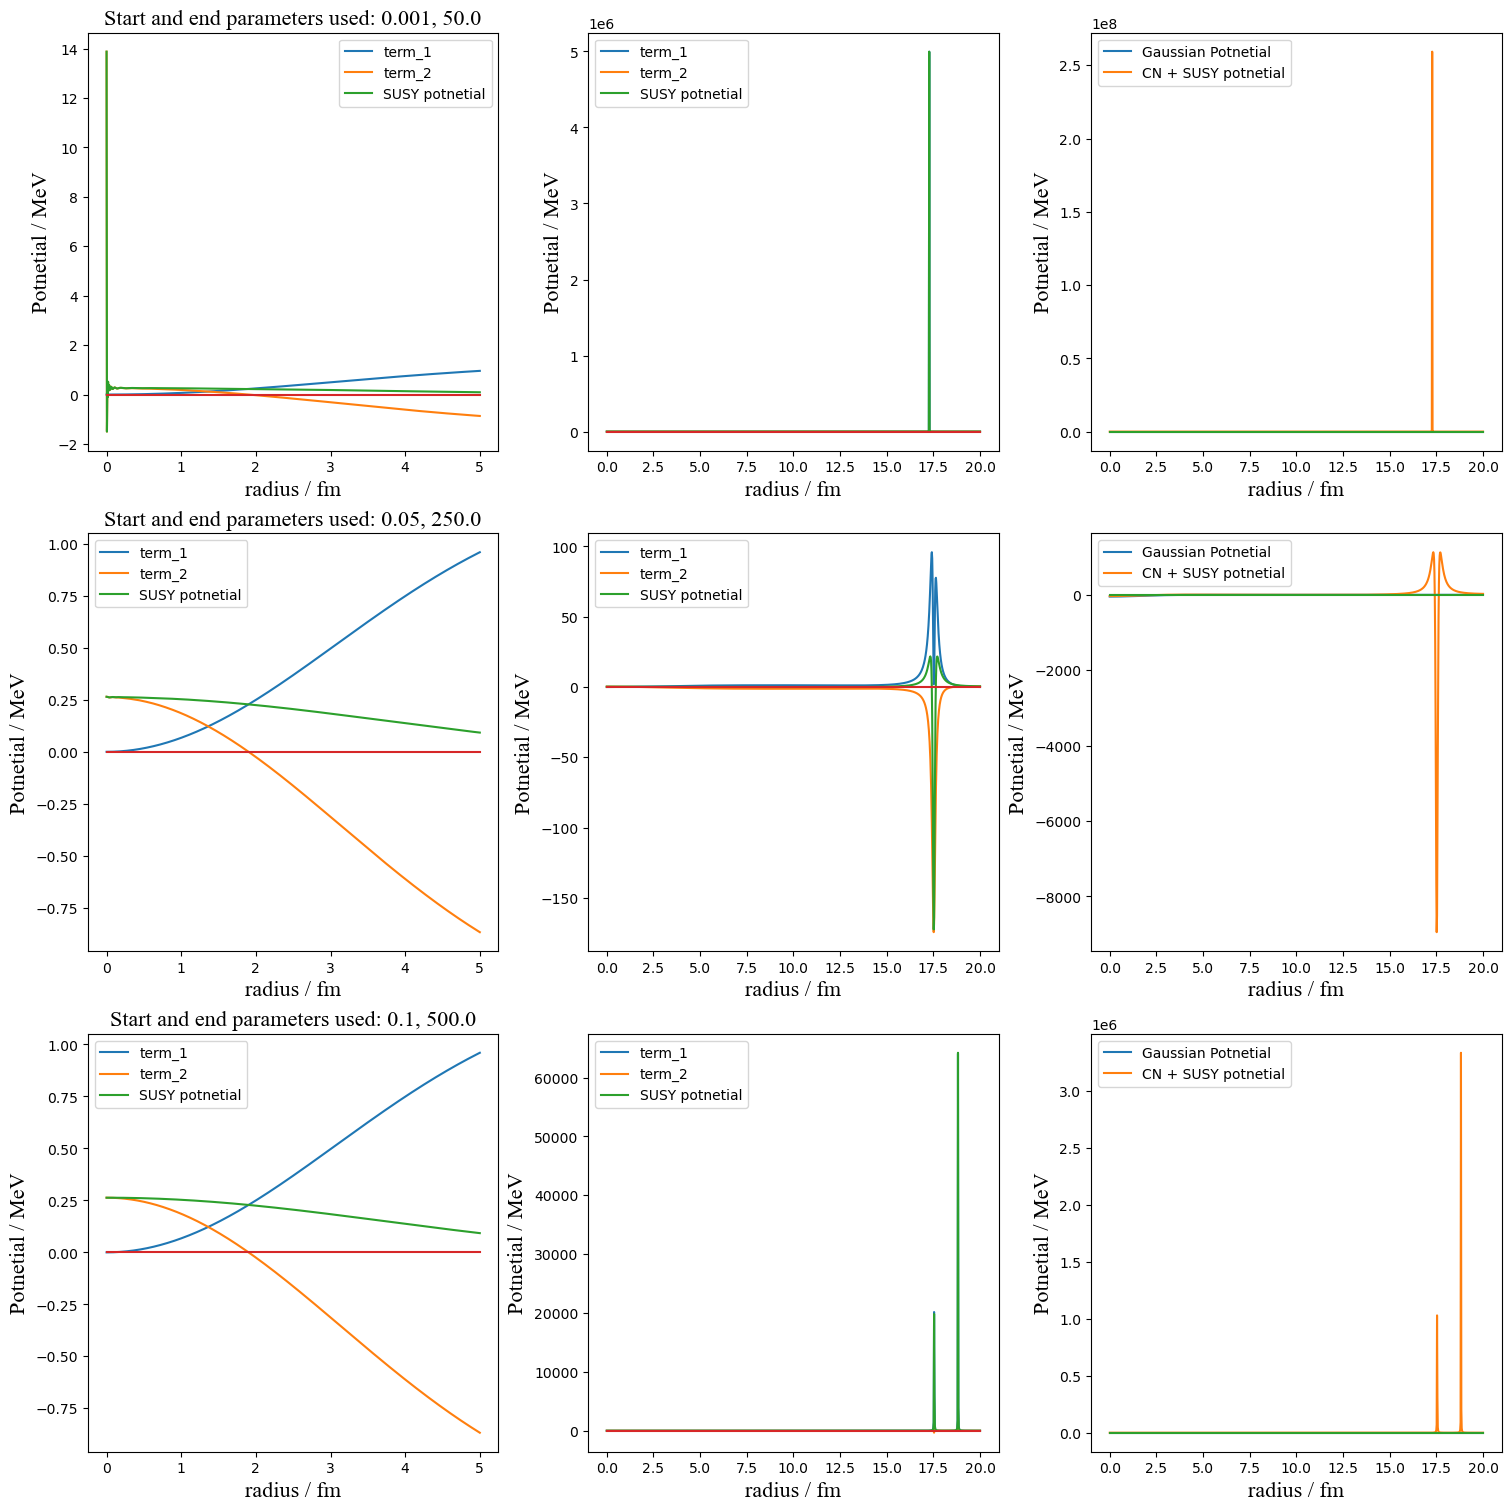

In [8]:
def gaussian_potnetial_plot_func(radius, V0=-47.32, beta=2.30):
    return V0 * np.exp(-radius**2 / beta**2)

def susy_parameter_set_generation(starting_range_param, ending_range_param, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i, starting_range_parameter=starting_range_param,
                                                 ending_range_parameter=ending_range_param)
        for j in range(size):
            j_range_parameter = next_range_parameter(j, starting_range_parameter=starting_range_param,
                                                     ending_range_parameter=ending_range_param)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)
    eigenvalues, eigenvectors = scipy.linalg.eigh(h_matrix, n_matrix)
    ground_state_eigenvector = eigenvectors[:, 0]
    return eigenvalues[0], ground_state_eigenvector

def new_susy_potential_plot_function(radius, mixing_coeffs, start_range_param, end_range_param, size=SUM_LIMIT):
    susy_term_1_vals = np.zeros(shape=(1, len(radius)))[0, :]
    susy_term_2_vals = np.zeros(shape=(1, len(radius)))[0, :]

    mixing_coeffs = np.real(mixing_coeffs)
    for i in enumerate(radius):
        term_1 = 0
        term_2 = 0
        term_3 = 0
        for k in enumerate(mixing_coeffs):
            #print(k)
            range_parameter = next_range_parameter(k[0], starting_range_parameter=start_range_param,
                                                   ending_range_parameter=end_range_param)
            term_1 += gauss_wavefunc(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_2 += gauss_wavefunc_first_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_3 += gauss_wavefunc_second_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
        susy_term_1_vals[i[0]] = (term_2 / term_1)**2
        susy_term_2_vals[i[0]] = -(term_3 / term_1)

    return susy_term_1_vals, susy_term_2_vals

range_params = np.array([[0.001, 0.05, 0.1],[50, 250, 500]])
eigenvalues = np.zeros((3,))
eigenvectors = [0, 0, 0]
for i in enumerate(range_params[0]):
    print(i[0])
    eigenvalues[i[0]], eigenvectors[i[0]] = susy_parameter_set_generation(range_params[0, i[0]], range_params[1, i[0]])
#eigenvalue, eigenvector = susy_parameter_set_generation(0.1, 25)

fig = plt.figure(figsize=(15, 15), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=3)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[0,2])
ax_4 = fig.add_subplot(spec[1,0])
ax_5 = fig.add_subplot(spec[1,1])
ax_6 = fig.add_subplot(spec[1,2])
ax_7 = fig.add_subplot(spec[2,0])
ax_8 = fig.add_subplot(spec[2,1])
ax_9 = fig.add_subplot(spec[2,2])

num_points_to_plot = 1000
ax_1_r_vals = np.linspace(0, 5, num_points_to_plot)
ax_2_r_vals = np.linspace(0, 20, num_points_to_plot)
ax_3_r_vals = np.linspace(0, 20, num_points_to_plot)
ax_4_r_vals = np.linspace(0, 5, num_points_to_plot)
ax_5_r_vals = np.linspace(0, 20, num_points_to_plot)
ax_6_r_vals = np.linspace(0, 20, num_points_to_plot)
ax_7_r_vals = np.linspace(0, 5, num_points_to_plot)
ax_8_r_vals = np.linspace(0, 20, num_points_to_plot)
ax_9_r_vals = np.linspace(0, 20, num_points_to_plot)

ax_1_susy_term_1_vals, ax_1_susy_term_2_vals = new_susy_potential_plot_function(ax_1_r_vals, eigenvectors[0],
                                                                                range_params[0, 0], range_params[1, 0])
ax_2_susy_term_1_vals, ax_2_susy_term_2_vals = new_susy_potential_plot_function(ax_2_r_vals, eigenvectors[0],
                                                                               range_params[0, 0], range_params[1, 0])
ax_3_susy_term_1_vals, ax_3_susy_term_2_vals = new_susy_potential_plot_function(ax_3_r_vals, eigenvectors[0],
                                                                               range_params[0, 0], range_params[1, 0])
ax_4_susy_term_1_vals, ax_4_susy_term_2_vals = new_susy_potential_plot_function(ax_4_r_vals, eigenvectors[1],
                                                                               range_params[0, 1], range_params[1, 1])
ax_5_susy_term_1_vals, ax_5_susy_term_2_vals = new_susy_potential_plot_function(ax_5_r_vals, eigenvectors[1],
                                                                               range_params[0, 1], range_params[1, 1])
ax_6_susy_term_1_vals, ax_6_susy_term_2_vals = new_susy_potential_plot_function(ax_6_r_vals, eigenvectors[1],
                                                                               range_params[0, 1], range_params[1, 1])
ax_7_susy_term_1_vals, ax_7_susy_term_2_vals = new_susy_potential_plot_function(ax_7_r_vals, eigenvectors[2],
                                                                               range_params[0, 2], range_params[1, 2])
ax_8_susy_term_1_vals, ax_8_susy_term_2_vals = new_susy_potential_plot_function(ax_8_r_vals, eigenvectors[2],
                                                                               range_params[0, 2], range_params[1, 2])
ax_9_susy_term_1_vals, ax_9_susy_term_2_vals = new_susy_potential_plot_function(ax_9_r_vals, eigenvectors[2],
                                                                               range_params[0, 2], range_params[1, 2])


ax_1.plot(ax_1_r_vals, ax_1_susy_term_1_vals, label='term_1')
ax_1.plot(ax_1_r_vals, ax_1_susy_term_2_vals, label='term_2')
ax_1.plot(ax_1_r_vals, ax_1_susy_term_1_vals + ax_1_susy_term_2_vals,
          label='SUSY potnetial')
ax_1.legend()
ax_1.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_1.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_1.plot(ax_1_r_vals, ax_1_r_vals*0)
ax_1.set_title(f'Start and end parameters used: {range_params[0, 0]}, {range_params[1,0]}', fontsize=16, fontname='Times New Roman')
ax_1.legend()

ax_2.plot(ax_2_r_vals, ax_2_susy_term_1_vals, label='term_1')
ax_2.plot(ax_2_r_vals, ax_2_susy_term_2_vals, label='term_2')
ax_2.plot(ax_2_r_vals, ax_2_susy_term_1_vals + ax_2_susy_term_2_vals,
          label='SUSY potnetial')
ax_2.legend()
ax_2.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_2.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_2.plot(ax_2_r_vals, ax_2_r_vals*0)
#ax_2.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_2.legend()

ax_3.plot(ax_3_r_vals, gaussian_potnetial_plot_func(ax_3_r_vals), label='Gaussian Potnetial')
ax_3.plot(ax_3_r_vals, gaussian_potnetial_plot_func(ax_3_r_vals) + ((197)**2 / REDUCED_MASS)* (ax_3_susy_term_1_vals + ax_3_susy_term_2_vals),
          label='CN + SUSY potnetial')
ax_3.legend()
ax_3.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_3.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_3.plot(ax_3_r_vals, ax_3_r_vals*0)
#ax_3.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_3.legend()

ax_4.plot(ax_4_r_vals, ax_4_susy_term_1_vals, label='term_1')
ax_4.plot(ax_4_r_vals, ax_4_susy_term_2_vals, label='term_2')
ax_4.plot(ax_4_r_vals, ax_4_susy_term_1_vals + ax_4_susy_term_2_vals,
          label='SUSY potnetial')
ax_4.legend()
ax_4.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_4.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_4.plot(ax_4_r_vals, ax_4_r_vals*0)
ax_4.set_title(f'Start and end parameters used: {range_params[0, 1]}, {range_params[1, 1]}', fontsize=16, fontname='Times New Roman')
ax_4.legend()

ax_5.plot(ax_5_r_vals, ax_5_susy_term_1_vals, label='term_1')
ax_5.plot(ax_5_r_vals, ax_5_susy_term_2_vals, label='term_2')
ax_5.plot(ax_5_r_vals, ax_5_susy_term_1_vals + ax_5_susy_term_2_vals,
          label='SUSY potnetial')
ax_5.legend()
ax_5.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_5.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_5.plot(ax_5_r_vals, ax_5_r_vals*0)
#ax_5.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_5.legend()

ax_6.plot(ax_6_r_vals, gaussian_potnetial_plot_func(ax_6_r_vals), label='Gaussian Potnetial')
ax_6.plot(ax_6_r_vals, gaussian_potnetial_plot_func(ax_6_r_vals) + ((197)**2 / REDUCED_MASS)* (ax_6_susy_term_1_vals + ax_6_susy_term_2_vals),
          label='CN + SUSY potnetial')
ax_6.legend()
ax_6.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_6.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_6.plot(ax_6_r_vals, ax_6_r_vals*0)
#ax_6.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_6.legend()

ax_7.plot(ax_7_r_vals, ax_7_susy_term_1_vals, label='term_1')
ax_7.plot(ax_7_r_vals, ax_7_susy_term_2_vals, label='term_2')
ax_7.plot(ax_7_r_vals, ax_7_susy_term_1_vals + ax_7_susy_term_2_vals,
          label='SUSY potnetial')
ax_7.legend()
ax_7.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_7.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_7.plot(ax_7_r_vals, ax_7_r_vals*0)
ax_7.set_title(f'Start and end parameters used: {range_params[0, 2]}, {range_params[1, 2]}', fontsize=16, fontname='Times New Roman')
ax_7.legend()

ax_8.plot(ax_8_r_vals, ax_8_susy_term_1_vals, label='term_1')
ax_8.plot(ax_8_r_vals, ax_8_susy_term_2_vals, label='term_2')
ax_8.plot(ax_8_r_vals, ax_8_susy_term_1_vals + ax_8_susy_term_2_vals,
          label='SUSY potnetial')
ax_8.legend()
ax_8.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_8.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_8.plot(ax_8_r_vals, ax_8_r_vals*0)
#ax_8.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_8.legend()

ax_9.plot(ax_9_r_vals, gaussian_potnetial_plot_func(ax_9_r_vals), label='Gaussian Potnetial')
ax_9.plot(ax_9_r_vals, gaussian_potnetial_plot_func(ax_9_r_vals) + ((197)**2 / REDUCED_MASS)* (ax_9_susy_term_1_vals + ax_9_susy_term_2_vals),
          label='CN + SUSY potnetial')
ax_9.legend()
ax_9.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_9.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_9.plot(ax_9_r_vals, ax_9_r_vals*0)
#ax_9.set_title('Title', fontsize=16, fontname='Times New Roman')
ax_9.legend()

plt.savefig('Different_range_params_potential_plot.png')

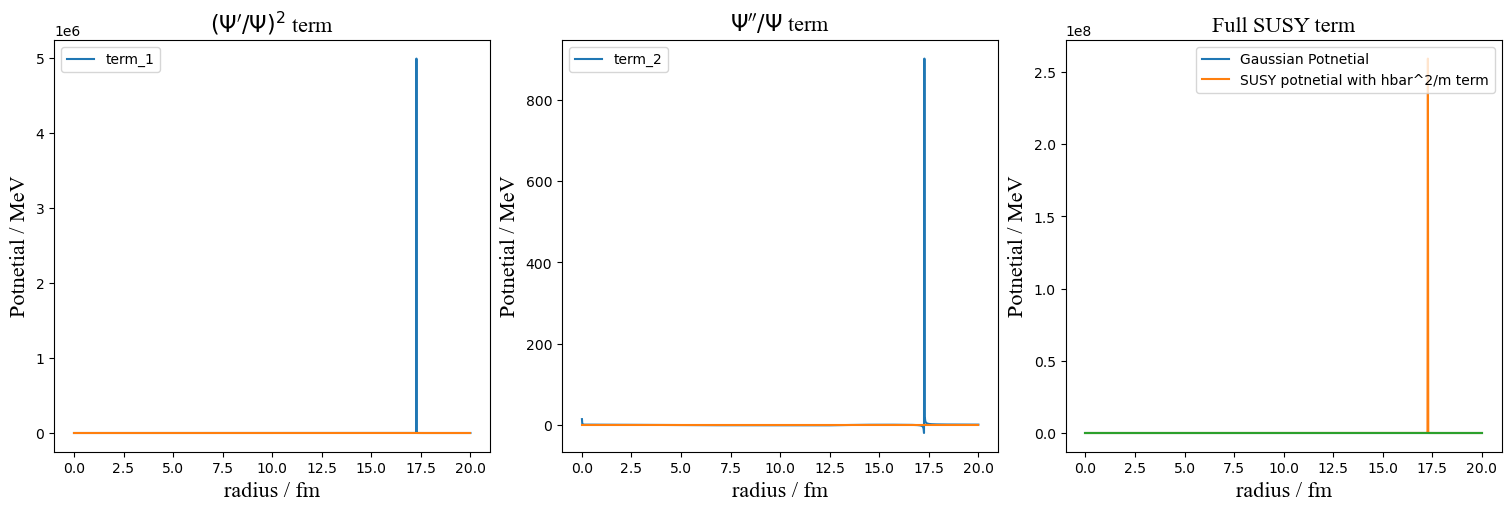

In [9]:
fig = plt.figure(figsize=(15, 5), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=1)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[0,2])

ax_1.plot(ax_2_r_vals, ax_2_susy_term_1_vals, label='term_1')

ax_1.legend()
ax_1.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_1.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_1.plot(ax_2_r_vals, ax_2_r_vals*0)
ax_1.set_title(r"$\left(\Psi' /\Psi \right)^{2}$ term", fontsize=16, fontname='Times New Roman')
ax_1.legend()

ax_2.plot(ax_2_r_vals, ax_2_susy_term_2_vals, label='term_2')

ax_2.legend()
ax_2.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_2.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_2.plot(ax_2_r_vals, ax_2_r_vals*0)
ax_2.set_title(r"$\Psi'' / \Psi$ term", fontsize=16, fontname='Times New Roman')
ax_2.legend()

ax_3.plot(ax_3_r_vals, gaussian_potnetial_plot_func(ax_3_r_vals), label='Gaussian Potnetial')
ax_3.plot(ax_3_r_vals, ((197)**2 / REDUCED_MASS)* (ax_3_susy_term_1_vals + ax_3_susy_term_2_vals),
          label='SUSY potnetial with hbar^2/m term')
ax_3.legend()
ax_3.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_3.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_3.plot(ax_3_r_vals, ax_3_r_vals*0)
ax_3.set_title('Full SUSY term', fontsize=16, fontname='Times New Roman')
ax_3.legend(loc='upper right')

plt.savefig('Term by term comparision.png')

In [10]:
new_constrained_theta_values = np.linspace(0, 35 * np.pi / 180, 36)
new_constrained_p_one_half_eigen_matrix = np.zeros(shape=(len(new_constrained_theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(new_constrained_theta_values):
    p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, i[1])
    p_one_half_eigenvalues, d_five_half_eigenvectors = scipy.linalg.eig(p_one_half_h_matrix, p_one_half_n_matrix)
    new_constrained_p_one_half_eigen_matrix[i[0], :] = p_one_half_eigenvalues

new_constrained_p_three_half_eigen_matrix = np.zeros(shape=(len(new_constrained_theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(new_constrained_theta_values):
    p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, i[1])
    p_three_half_eigenvalues, p_three_half_eigenvectors = scipy.linalg.eig(p_three_half_h_matrix, p_three_half_n_matrix)
    new_constrained_p_three_half_eigen_matrix[i[0], :] = p_three_half_eigenvalues

TypeError: object of type 'float' has no len()

In [ ]:
def straight_line_angle(x_vals, theta):
    # theta = 2 * theta * np.pi / 180
    return x_vals * np.tan(- 2 * theta)


x_vals = np.linspace(0, 10, 1000)

cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 36))
font_size_variable = 16
tick_size_variable = 12
legend_font = font_manager.FontProperties(family='Times New Roman',
                                          style='normal', size=14)

fig = plt.figure(figsize=(13, 5), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=1)
ax_1 = fig.add_subplot(spec[0, 0])
ax_2 = fig.add_subplot(spec[0, 1])

ax_1_title = (r'$\theta$ values $0^{\circ} \rightarrow 4^{\circ}$')

#print(new_constrained_d_five_half_eigen_matrix)

for i in enumerate(new_constrained_theta_values):
    ax_1.scatter(np.real(new_constrained_p_one_half_eigen_matrix[i[0], :]),
                 np.imag(new_constrained_p_one_half_eigen_matrix[i[0], :]), color=colors[i[0]], marker='x', s=100)
    if i[0] % 5 == 0:
        line_label_1 = fr'$\theta =${round(i[1] * 2 * 180 / np.pi)}'
        line_label_2 = r'$^\circ$'
        line_label = line_label_1 + line_label_2
        ax_1.plot(x_vals, straight_line_angle(x_vals, i[1]), label=line_label, color=colors[i[0]])
# label=(r'$\theta', f'= {i[1] * 180 / np.pi:.1f}', r'^{\circ}$'),
        
    
ax_1.set_xlim(left=0, right=6)
ax_1.set_ylim(bottom=-5, top=0.1)
ax_1.set_xlabel('Real Axis (Energy / MeV)', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_ylabel('Imaginary Axis', fontsize=font_size_variable, fontname='Times New Roman')
ax_1.grid(color='darkslategrey', dashes=[6, 3, 6, 3])
ax_1.tick_params(axis='both', labelsize=tick_size_variable)
ax_1.legend(prop=legend_font)
ax_1.set_title('p1/2')


for i in enumerate(new_constrained_theta_values):
    ax_2.scatter(np.real(new_constrained_p_three_half_eigen_matrix[i[0], :]),
                 np.imag(new_constrained_p_three_half_eigen_matrix[i[0], :]), color=colors[i[0]], marker='x', s=100)
    if i[0] % 5 == 0:
        line_label_1 = fr'$\theta =${round(i[1] * 2 * 180 / np.pi)}'
        line_label_2 = r'$^\circ$'
        line_label = line_label_1 + line_label_2
        ax_2.plot(x_vals, straight_line_angle(x_vals, i[1]), label=line_label, color=colors[i[0]])
# label=(r'$\theta', f'= {i[1] * 180 / np.pi:.1f}', r'^{\circ}$'),
        
    
ax_2.set_xlim(left=0, right=6)
ax_2.set_ylim(bottom=-5, top=0.1)
ax_2.set_xlabel('Real Axis (Energy / MeV)', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_ylabel('Imaginary Axis', fontsize=font_size_variable, fontname='Times New Roman')
ax_2.grid(color='darkslategrey', dashes=[6, 3, 6, 3])
ax_2.tick_params(axis='both', labelsize=tick_size_variable)
ax_2.legend(prop=legend_font)
ax_2.set_title('p3/2')



#plt.savefig('d_five_half_Complex_resonance_plot.png')

In [ ]:
theta_values = np.linspace(0, 0.59, 500)
p_one_half_eigenvalue_theta_matrix = np.zeros(shape=(len(theta_values), SUM_LIMIT), dtype=np.complex_)
p_three_half_eigenvalue_theta_matrix = np.zeros(shape=(len(theta_values), SUM_LIMIT), dtype=np.complex_)
for i in enumerate(theta_values):
    p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, i[1])
    p_one_half_eigenvalues, p_one_half_eigenvectors = scipy.linalg.eig(p_one_half_h_matrix, p_one_half_n_matrix)
    p_one_half_eigenvalue_theta_matrix[i[0], :] = p_one_half_eigenvalues
    p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, i[1])
    p_three_half_eigenvalues, p_three_half_eigenvectors = scipy.linalg.eig(p_three_half_h_matrix, p_three_half_n_matrix)
    p_three_half_eigenvalue_theta_matrix[i[0], :] = p_three_half_eigenvalues

In [ ]:
fig = plt.figure(figsize=(15, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=1)
ax_1 = fig.add_subplot(spec[0, :])
#ax_2 = fig.add_subplot(spec[0, 1])

for i in enumerate(theta_values):
    ax_1.scatter(np.real(p_one_half_eigenvalue_theta_matrix[i[0], 17]),
                np.imag(p_one_half_eigenvalue_theta_matrix[i[0], 17]), c=(p_one_half_eigenvalue_theta_matrix[i[0], 17]), cmap='viridis')
ax_1.set_xlabel('Real Axis')
ax_1.set_ylabel('Imaginary Axis')
ax_1.set_title(r'$p_{1/2}$')
ax_1
plt.show()
plt.close()


In [ ]:
constrained_region_matrix = np.zeros(shape=(0, 2))

for i in enumerate(theta_values):
    for j in range(SUM_LIMIT):
        if 0.8 < np.real(p_one_half_eigenvalue_theta_matrix[i[0], j]) < 1.1 and -0.5 < np.imag(p_one_half_eigenvalue_theta_matrix[i[0], j]) < -0.2:
            constrained_region_matrix = np.append(constrained_region_matrix, p_one_half_eigenvalue_theta_matrix[i[0], j])

change_in_energy = np.zeros(shape=(1, len(constrained_region_matrix)-1))
for i in enumerate(change_in_energy[0, :]):
    change_in_energy[0, i[0]] = np.abs(constrained_region_matrix[i[0] + 1] - constrained_region_matrix[i[0]])
change_in_energy = change_in_energy[0, :]
print(f'Value where minimum change of energy occurs is at {constrained_region_matrix[np.where(change_in_energy == change_in_energy.min())]}')

fig = plt.figure(figsize=(15, 10), layout='constrained')
ax = fig.add_subplot()
#for i in enumerate(theta_values):
#    ax.scatter(np.real(p_one_half_eigenvalue_theta_matrix[i[0], :]),
#               np.imag(p_one_half_eigenvalue_theta_matrix[i[0], :]), marker='x', s=1, c=(p_one_half_eigenvalue_theta_matrix[i[0], :]), cmap='viridis')
ax.scatter(np.real(constrained_region_matrix),
            np.imag(constrained_region_matrix), marker='x', s=1, c='b')
#ax.scatter(1.274, -0.05, s = 100, c='r')
ax.plot(np.linspace(0.99350506, 0.99350506, 100), np.linspace(-0.5, 0.03, 100), label='Energy value of resonance')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
ax.set_title(r'$p_{1/2}$')
ax.set_xlim(left=0.8, right=1.1)
ax.set_ylim(bottom=-0.5, top=-0.3)
ax.legend()
#ax.set_xlim(left=1, right=2)
#ax.set_ylim(bottom=-2, top=0)
plt.savefig('Resonance_location.png')
plt.show()
plt.close()


### gaussian potential estimate

max difference between susy potential and gaussian estimate = 0.18322546856734334 MeV, at r = 0


C:\Users\w27576eb\AppData\Local\Temp\ipykernel_17124\2353231899.py:24: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr).nonzero()` if the old behavior was intended.
  max_diff_loc = np.where(max_diff)[0][0]


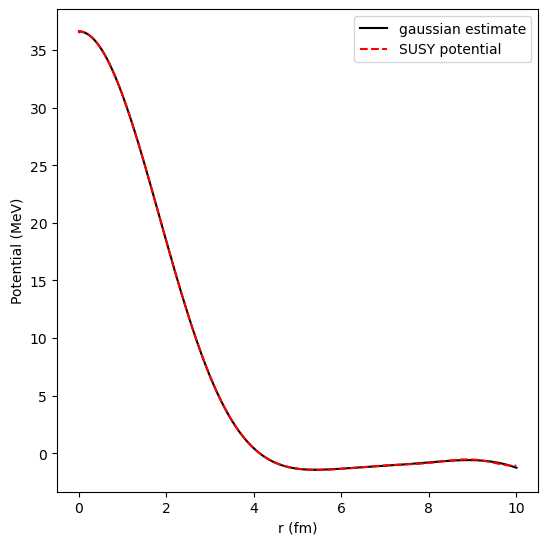

In [26]:
NUM_SUSY_GAUSSIANS = 15
SUSY_POTENTIAL_PARAMS = [0.694444, 0.482253, 0.334898, 0.232568, 0.161506, 0.112157, 0.0778866, 0.0540879, 0.037561,
                         0.0260841, 0.0181139, 0.0125791, 0.0087355, 0.00606632, 0.00421272]
SUSY_POTENTIAL_COEFFS = [-3.96307,30.5414,-120.512,315.402,-622.575,1070.74,-1121.61,423.361,544.51,-544.566,-293.377,272.053,267.435,-20.9172,-159.915]
SUSY_R0 = 1.2
SUSY_A = 1.2

def potential_estimate(r, betas, coeffs):
    potential = 0
    for i in range(len(betas)):
        potential += coeffs[i] * np.exp(-1 * betas[i] * r**2)
    return potential

susy_potential = potential_estimate(r_vals, SUSY_POTENTIAL_PARAMS, SUSY_POTENTIAL_COEFFS)

fig = plt.figure(figsize=(15, 15), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=3)
ax_1 = fig.add_subplot(spec[0,0])

ax_1.plot(r_vals, susy_potential, label='gaussian estimate', color='k')
ax_1.plot(r_vals, susy_term_1_vals + susy_term_2_vals, label='SUSY potential', color='r', linestyle='--')

max_diff = np.max(np.abs(susy_potential - (susy_term_1_vals+susy_term_2_vals)))
max_diff_loc = np.where(max_diff)[0][0]
print("max difference between susy potential and gaussian estimate =", max_diff, "MeV, at r =", max_diff_loc)

ax_1.set_ylabel("Potential (MeV)")
ax_1.set_xlabel("r (fm)")

plt.legend()
plt.show()